## 基于深度偏移 LAS 构建深度域低频模型

本 notebook 读取 `wavelet_batch_synthetic_depth@20260427.ipynb` 导出的 `shifted_las` 子目录中的 LAS 曲线、`data/raw/well_heads` 中的井头 KB，以及 `data/interpre_depth` 中的深度域层位解释，调用 `cup.seismic.lfm_depth` 构建 TVDSS 深度域低频模型。

输入 LAS 的 `DEPT` 已经包含井震标定得到的深度偏移；本 notebook 只做 `TVDSS = shifted_MD - KB`。

输出两套体：

- `Vp` 低频模型：`vp_lfm_depth.npz` 与 `vp_lfm_depth.segy`
- `AI = Vp * Rho` 低频模型：`ai_lfm_depth.npz` 与 `ai_lfm_depth.segy`


In [12]:
import json
import sys
from pathlib import Path

import cigsegy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
if not (repo_root / "src").exists():
    raise RuntimeError("Could not locate repo root containing 'src'.")

src_root = repo_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from cup.petrel.load import (
    import_interpretation_petrel,
    import_well_heads_petrel,
    load_vp_rho_logset_from_las,
)
from cup.seismic.lfm_depth import LfmDepthWell, build_lfm_depth_model
from cup.seismic.survey import open_survey
from cup.seismic.target_layer import TargetLayer
from wtie.processing import grid


In [13]:
data_root = repo_root / "data"

output_dir = data_root / "output_lfm_depth_from_las_20260428"
vp_output_file = output_dir / "vp_lfm_depth.npz"
vp_output_segy_file = output_dir / "vp_lfm_depth.segy"
ai_output_file = output_dir / "ai_lfm_depth.npz"
ai_output_segy_file = output_dir / "ai_lfm_depth.segy"

train_config_file = repo_root / "experiments" / "ginn_depth" / "train.yaml"
target_layer_qc_dir = output_dir / "target_layer_qc"

well_heads_file = data_root / "raw" / "well_heads"
wavelet_batch_output_dir = data_root / "output_wavelet_batch_synthetic_depth_20260428"
las_dir = wavelet_batch_output_dir / "shifted_las"

seismic_file = data_root / "raw" / "mero_84_coord_extend"
segy_options = {
    "iline": 5,
    "xline": 21,
    "istep": 1,
    "xstep": 4,
}
keylocs = [
    segy_options["iline"],
    segy_options["xline"],
    segy_options["istep"],
    segy_options["xstep"],
]

horizon_files = {
    "base_of_salt": data_root / "interpre_depth" / "base_of_salt_extend",
    "base_of_bve": data_root / "interpre_depth" / "base_of_bve_extend",
    "base_of_itp": data_root / "interpre_depth" / "base_of_itp_extend",
}

for path in [train_config_file, well_heads_file, las_dir, seismic_file, *horizon_files.values()]:
    if not path.exists():
        raise FileNotFoundError(path)

with train_config_file.open("r", encoding="utf-8") as file:
    train_config = yaml.safe_load(file)

target_layer_config = {
    "min_thickness": train_config.get("target_layer_min_thickness"),
    "nearest_distance_limit": train_config.get("target_layer_nearest_distance_limit"),
    "outlier_threshold": train_config.get("target_layer_outlier_threshold"),
    "outlier_min_neighbor_count": train_config.get("target_layer_outlier_min_neighbor_count"),
}

lfm_build_params = {
    "boundary_extension_samples": 50,
    "n_slices": 20,
    "variogram": "spherical",
    "exact": True,
    "nugget": 0.0,
    "filter_cutoff_wavelength_m": 250.0,
    "filter_order": 6,
    "filter_buffer_meters": None,
    "filter_buffer_mode": "reflect",
    "post_slice_smoothing": False,
}

las_files = sorted(las_dir.glob("*.las"))
if not las_files:
    raise ValueError(f"No LAS files found in {las_dir}")

print("Output dir:", output_dir)
print("Shifted LAS dir:", las_dir)
print("LAS count:", len(las_files))
las_dir


Output dir: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\data\output_lfm_depth_from_las_20260428
Shifted LAS dir: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\data\output_wavelet_batch_synthetic_depth_20260428\shifted_las
LAS count: 7


WindowsPath('c:/Users/WangQinZhuo/Program/libra_workflow_standardize/data/output_wavelet_batch_synthetic_depth_20260428/shifted_las')

## 1) 构造深度域工区几何与目的层


In [14]:
survey = open_survey(
    seismic_file,
    seismic_type="segy",
    segy_options=segy_options,
)
geometry_depth = survey.query_geometry(domain="depth")

print(json.dumps(geometry_depth, indent=2, ensure_ascii=False))
assert geometry_depth["sample_domain"] == "depth"
assert geometry_depth["sample_unit"] == "m"
assert geometry_depth["sample_step"] == 5.0


100%|██████████| 481401/481401 [00:00<00:00, 2516130.81it/s]

{
  "n_il": 601,
  "inline_min": 1501.0,
  "inline_max": 2101.0,
  "inline_step": 1.0,
  "n_xl": 801,
  "xline_min": 3799.0,
  "xline_max": 6999.0,
  "xline_step": 4.0,
  "n_sample": 551,
  "sample_min": 4750.0,
  "sample_max": 7500.0,
  "sample_step": 5.0,
  "sample_domain": "depth",
  "sample_unit": "m"
}


In [15]:
def build_target_layer(geometry: dict) -> TargetLayer:
    raw_horizons = {
        horizon_name: import_interpretation_petrel(horizon_file) for horizon_name, horizon_file in horizon_files.items()
    }

    return TargetLayer(
        raw_horizon_dfs=raw_horizons,
        geometry=geometry,
        horizon_names=list(horizon_files.keys()),
        qc_output_dir=target_layer_qc_dir,
        min_thickness=target_layer_config["min_thickness"],
        nearest_distance_limit=target_layer_config["nearest_distance_limit"],
        outlier_threshold=target_layer_config["outlier_threshold"],
        outlier_min_neighbor_count=target_layer_config["outlier_min_neighbor_count"],
    )


target_layer = build_target_layer(geometry_depth)

print("horizons:", target_layer.horizon_names)
print("zones:", target_layer.iter_zones())
print("QC dir:", target_layer_qc_dir)
display(target_layer.qc_summary_df)


horizons: ['base_of_salt', 'base_of_bve', 'base_of_itp']
zones: [('base_of_salt', 'base_of_bve'), ('base_of_bve', 'base_of_itp')]
QC dir: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\data\output_lfm_depth_from_las_20260428\target_layer_qc


,record_type,horizon_pair,top_name,bottom_name,total_traces,pair_no_support_count,crossing_count,thin_count,pair_valid_count,min_thickness,outlier_enabled,outlier_threshold,outlier_min_neighbor_count,outlier_total_points,outlier_removed_points,outlier_removed_ratio,filled_model_count,filled_by_thickness_interpolation_count,nearest_distance_limit
0,horizon,base_of_salt,base_of_salt,,481401,3,0,0,481398,5.0,False,NaN,2.0,448368.0,0.0,0.0,NaN,NaN,NaN
1,horizon,base_of_bve,base_of_bve,,481401,0,0,0,481401,5.0,False,NaN,2.0,442323.0,0.0,0.0,NaN,NaN,NaN
2,horizon,base_of_itp,base_of_itp,,481401,0,0,0,481401,5.0,False,NaN,2.0,422612.0,0.0,0.0,NaN,NaN,NaN
3,pair,base_of_salt->base_of_bve,base_of_salt,base_of_bve,481401,3,244,19,481135,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,pair,base_of_bve->base_of_itp,base_of_bve,base_of_itp,481401,0,622,80,480699,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,global,__trace_global__,,,481401,3,866,99,480433,5.0,NaN,NaN,2.0,NaN,NaN,NaN,481401.0,968.0,NaN


## 2) 读取 LAS 并构造 KB 直井近似井控


In [16]:
def collect_well_records(las_files: list[Path], well_heads_file: Path) -> tuple[list[dict], pd.DataFrame]:
    well_heads_df = import_well_heads_petrel(well_heads_file)
    head_lookup = well_heads_df.copy()
    head_lookup["_name_norm"] = head_lookup["Name"].astype(str).str.strip()
    head_lookup = head_lookup.set_index("_name_norm", drop=False)

    records = []
    summary_rows = []
    for las_file in las_files:
        well_name = las_file.stem
        if well_name not in head_lookup.index:
            raise KeyError(f"Well '{well_name}' not found in well heads file.")

        head = head_lookup.loc[well_name]
        well_x = float(head["Surface X"])
        well_y = float(head["Surface Y"])
        kb_m = float(head["Well datum value"])
        inline, xline = survey.coord_to_line(well_x, well_y)
        horizon_depths = target_layer.get_interpretation_values_at_location(inline, xline)

        logset_md = load_vp_rho_logset_from_las(
            las_file,
            vp_mnemonic="VP_MPS",
            rho_mnemonic="RHO_GCC",
            vp_unit="m/s",
            rho_unit="g/cm3",
        )
        md_m = logset_md.basis.astype(float)
        tvdss_m = md_m - kb_m
        vp_values = np.asarray(logset_md.Vp.values, dtype=float)
        rho_values = np.asarray(logset_md.Rho.values, dtype=float)
        ai_values = np.asarray(logset_md.AI.values, dtype=float)

        record = {
            "well_name": well_name,
            "las_file": las_file,
            "logset_md": logset_md,
            "x": well_x,
            "y": well_y,
            "inline": float(inline),
            "xline": float(xline),
            "kb": kb_m,
            "horizon_depths": {name: float(value) for name, value in horizon_depths.items()},
        }
        records.append(record)

        summary_rows.append(
            {
                "well_name": well_name,
                "inline": float(inline),
                "xline": float(xline),
                "kb_m": kb_m,
                "md_min_m": float(np.nanmin(md_m)),
                "md_max_m": float(np.nanmax(md_m)),
                "tvdss_min_m": float(np.nanmin(tvdss_m)),
                "tvdss_max_m": float(np.nanmax(tvdss_m)),
                "vp_min_mps": float(np.nanmin(vp_values)),
                "vp_max_mps": float(np.nanmax(vp_values)),
                "rho_min_gcc": float(np.nanmin(rho_values)),
                "rho_max_gcc": float(np.nanmax(rho_values)),
                "ai_min": float(np.nanmin(ai_values)),
                "ai_max": float(np.nanmax(ai_values)),
                **{f"horizon_{name}_m": float(value) for name, value in horizon_depths.items()},
            }
        )

    return records, pd.DataFrame.from_records(summary_rows)


well_records, well_summary = collect_well_records(las_files, well_heads_file)
display(well_summary)


,well_name,inline,xline,kb_m,md_min_m,md_max_m,tvdss_min_m,tvdss_max_m,vp_min_mps,vp_max_mps,rho_min_gcc,rho_max_gcc,ai_min,ai_max,horizon_base_of_salt_m,horizon_base_of_bve_m,horizon_base_of_itp_m
0,2-ANP-2A-RJS,1684.089741,6352.693436,18.0,2040.503968,6087.803968,2022.503968,6069.803968,2067.454130,6343.694239,1.981401,3.001706,6167.169696,18362.303794,5417.587150,5628.160485,6085.034130
1,L1-NW1,1785.527488,5851.662032,26.0,5155.461809,5737.061809,5129.461809,5711.061809,2913.773358,6604.386288,2.252510,3.033230,6872.289813,19898.583932,5138.105541,5280.933234,5565.951444
2,L5-NW5,1996.342431,6786.176524,24.0,4852.821129,5768.121129,4828.821129,5744.121129,2493.091368,7303.136750,1.985836,3.064872,5140.774346,19414.911724,5093.622976,5490.722997,5740.877028
3,L9-NW4A,1779.181903,6261.682676,24.0,5320.587947,5854.387947,5296.587947,5830.387947,3233.719761,6258.154663,2.276269,2.972413,7677.022100,17828.110084,5315.871380,5536.517698,5939.828083
4,NW11,1631.445778,5982.130544,25.0,5500.518366,5983.718366,5475.518366,5958.718366,3476.975008,6366.592199,2.112836,2.977792,7803.108750,18051.309009,5493.537339,5723.970576,5963.642851
5,NW7,1698.520221,5057.081544,24.0,5257.824426,5664.724426,5233.824426,5640.724426,2591.015980,6665.789196,2.109607,2.986869,5466.025449,18920.451024,5185.759661,5374.243851,5524.159840
6,NW8,1606.563202,4100.662090,25.0,3626.862435,5911.162435,3601.862435,5886.162435,3752.987378,5809.221675,2.123121,2.994043,8311.210264,17150.665552,5320.182982,5799.183888,6055.988620


In [17]:
def build_tvdss_log_from_md(
    log_md: grid.Log,
    *,
    kb_m: float,
    dz_m: float,
) -> grid.Log:
    md_m = np.asarray(log_md.basis, dtype=float)
    values = np.asarray(log_md.values, dtype=float)
    tvdss_m = md_m - float(kb_m)

    finite = np.isfinite(tvdss_m) & np.isfinite(values)
    if int(finite.sum()) < 2:
        raise ValueError(f"Log {log_md.name!r} has too few finite samples.")

    tvdss_m = tvdss_m[finite]
    values = values[finite]
    order = np.argsort(tvdss_m)
    tvdss_m = tvdss_m[order]
    values = values[order]
    unique_depth, unique_depth_idx = np.unique(tvdss_m, return_index=True)
    unique_values = values[unique_depth_idx]
    if unique_depth.size < 2:
        raise ValueError(f"Log {log_md.name!r} has too few unique TVDSS samples.")

    regular_depth = np.arange(float(unique_depth[0]), float(unique_depth[-1]) + 0.5 * dz_m, float(dz_m))
    regular_values = np.interp(regular_depth, unique_depth, unique_values)

    return grid.Log(
        regular_values.astype(np.float64),
        regular_depth.astype(np.float64),
        "tvdss",
        name=log_md.name,
        unit=getattr(log_md, "unit", None),
        allow_nan=False,
    )


def build_lfm_wells(well_records: list[dict], property_name: str) -> list[LfmDepthWell]:
    if property_name not in {"Vp", "AI"}:
        raise ValueError(f"Unsupported property_name={property_name!r}")

    dz_m = float(geometry_depth["sample_step"])
    wells = []
    for record in well_records:
        logset_md = record["logset_md"]
        property_log_md = logset_md.Vp if property_name == "Vp" else logset_md.AI
        property_log = build_tvdss_log_from_md(
            property_log_md,
            kb_m=float(record["kb"]),
            dz_m=dz_m,
        )
        wells.append(
            LfmDepthWell(
                well_name=record["well_name"],
                property_name=property_name,
                property_log=property_log,
                x=record["x"],
                y=record["y"],
                kb=record["kb"],
                metadata={
                    "las_file": str(record["las_file"]),
                    "kb_m": float(record["kb"]),
                    "depth_conversion_assumption": "wavelet_batch_shifted_MD_minus_KB",
                    "input_basis_type_before_tvdss": property_log_md.basis_type,
                    "input_basis_type": property_log.basis_type,
                    "input_unit": getattr(property_log, "unit", ""),
                },
            )
        )
    return wells


vp_wells = build_lfm_wells(well_records, "Vp")
ai_wells = build_lfm_wells(well_records, "AI")

print("Vp wells:", [well.well_name for well in vp_wells])
print("AI wells:", [well.well_name for well in ai_wells])


Vp wells: ['2-ANP-2A-RJS', 'L1-NW1', 'L5-NW5', 'L9-NW4A', 'NW11', 'NW7', 'NW8']
AI wells: ['2-ANP-2A-RJS', 'L1-NW1', 'L5-NW5', 'L9-NW4A', 'NW11', 'NW7', 'NW8']


## 3) 构建 Vp 与 AI 深度域低频模型


In [18]:
def print_model_summary(label: str, result) -> None:
    print(f"[{label}] volume shape:", result.volume.shape)
    print(f"[{label}] variance shape:", result.variance_volume.shape)
    print(f"[{label}] sample range:", float(result.samples[0]), "to", float(result.samples[-1]))
    print(f"[{label}] property:", result.metadata["property_name"])
    print(f"[{label}] zones:", result.metadata["zone_names"])
    print(f"[{label}] wells:", result.metadata["well_names"])


vp_result = build_lfm_depth_model(
    target_layer=target_layer,
    wells=vp_wells,
    survey=survey,
    **lfm_build_params,
)
print_model_summary("Vp", vp_result)

ai_result = build_lfm_depth_model(
    target_layer=target_layer,
    wells=ai_wells,
    survey=survey,
    **lfm_build_params,
)
print_model_summary("AI", ai_result)


[Vp] volume shape: (601, 801, 551)
[Vp] variance shape: (601, 801, 551)
[Vp] sample range: 4750.0 to 7500.0
[Vp] property: Vp
[Vp] zones: [['top_extension', 'base_of_salt'], ['base_of_salt', 'base_of_bve'], ['base_of_bve', 'base_of_itp'], ['base_of_itp', 'bottom_extension']]
[Vp] wells: ['2-ANP-2A-RJS', 'L1-NW1', 'L5-NW5', 'L9-NW4A', 'NW11', 'NW7', 'NW8']
[AI] volume shape: (601, 801, 551)
[AI] variance shape: (601, 801, 551)
[AI] sample range: 4750.0 to 7500.0
[AI] property: AI
[AI] zones: [['top_extension', 'base_of_salt'], ['base_of_salt', 'base_of_bve'], ['base_of_bve', 'base_of_itp'], ['base_of_itp', 'bottom_extension']]
[AI] wells: ['2-ANP-2A-RJS', 'L1-NW1', 'L5-NW5', 'L9-NW4A', 'NW11', 'NW7', 'NW8']


## 4) 快速可视化


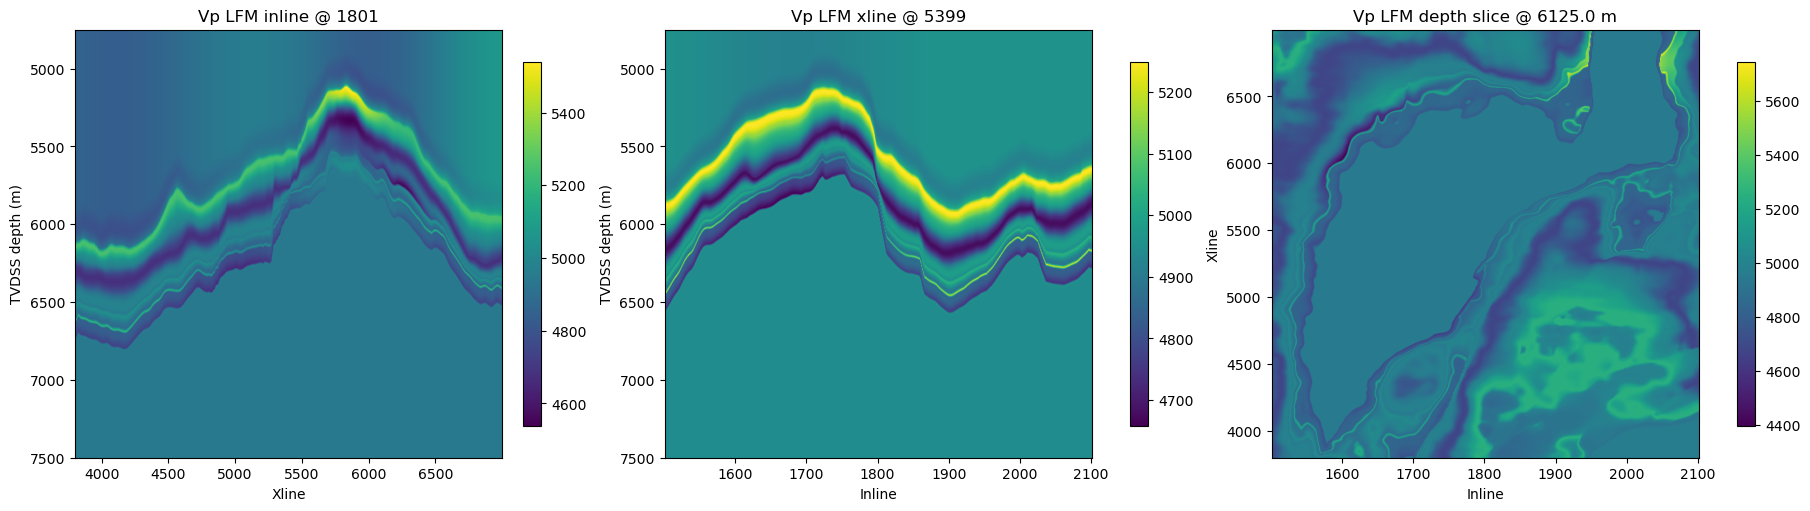

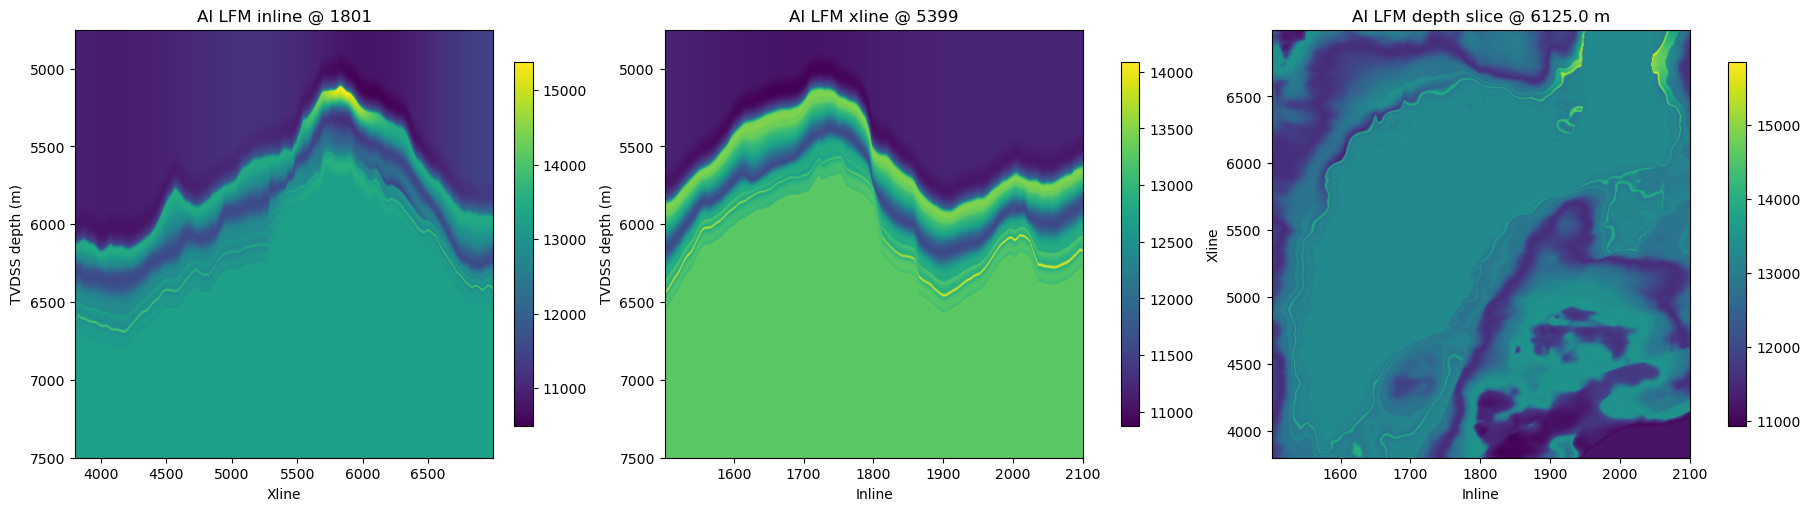

In [19]:
def plot_lfm_result(result, title: str, cmap: str = "viridis") -> None:
    ilines = result.ilines
    xlines = result.xlines
    samples = result.samples
    volume = result.volume

    i_il = len(ilines) // 2
    i_xl = len(xlines) // 2
    i_z = len(samples) // 2

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

    im0 = axes[0].imshow(
        volume[i_il, :, :].T,
        aspect="auto",
        origin="upper",
        extent=[xlines[0], xlines[-1], samples[-1], samples[0]],
        cmap=cmap,
    )
    axes[0].set_title(f"{title} inline @ {ilines[i_il]:.0f}")
    axes[0].set_xlabel("Xline")
    axes[0].set_ylabel("TVDSS depth (m)")
    fig.colorbar(im0, ax=axes[0], shrink=0.85)

    im1 = axes[1].imshow(
        volume[:, i_xl, :].T,
        aspect="auto",
        origin="upper",
        extent=[ilines[0], ilines[-1], samples[-1], samples[0]],
        cmap=cmap,
    )
    axes[1].set_title(f"{title} xline @ {xlines[i_xl]:.0f}")
    axes[1].set_xlabel("Inline")
    axes[1].set_ylabel("TVDSS depth (m)")
    fig.colorbar(im1, ax=axes[1], shrink=0.85)

    im2 = axes[2].imshow(
        volume[:, :, i_z].T,
        aspect="auto",
        origin="lower",
        extent=[ilines[0], ilines[-1], xlines[0], xlines[-1]],
        cmap=cmap,
    )
    axes[2].set_title(f"{title} depth slice @ {samples[i_z]:.1f} m")
    axes[2].set_xlabel("Inline")
    axes[2].set_ylabel("Xline")
    fig.colorbar(im2, ax=axes[2], shrink=0.85)

    plt.show()


plot_lfm_result(vp_result, "Vp LFM")
plot_lfm_result(ai_result, "AI LFM")


In [20]:
def summarize_coverage(result) -> pd.DataFrame:
    rows = []
    for zone_name, zone_stats in result.coverage_stats["zones"].items():
        counts = np.asarray(zone_stats["slice_control_counts"], dtype=int)
        rows.append(
            {
                "property": result.metadata["property_name"],
                "zone": zone_name,
                "n_slices": int(counts.size),
                "min_controls": int(np.min(counts)),
                "max_controls": int(np.max(counts)),
                "mean_controls": float(np.mean(counts)),
                "modes": ";".join(sorted(set(zone_stats["slice_modes"]))),
            }
        )
    return pd.DataFrame.from_records(rows)


display(pd.concat([summarize_coverage(vp_result), summarize_coverage(ai_result)], ignore_index=True))


,property,zone,n_slices,min_controls,max_controls,mean_controls,modes
0,Vp,top_extension->base_of_salt,20,3,6,3.25,kriging
1,Vp,base_of_salt->base_of_bve,20,6,7,6.75,kriging
2,Vp,base_of_bve->base_of_itp,20,3,7,5.95,kriging
3,Vp,base_of_itp->bottom_extension,20,0,3,1.05,kriging;neighbor_slice_fill;single_well_constant
4,AI,top_extension->base_of_salt,20,3,6,3.25,kriging
5,AI,base_of_salt->base_of_bve,20,6,7,6.75,kriging
6,AI,base_of_bve->base_of_itp,20,3,7,5.95,kriging
7,AI,base_of_itp->bottom_extension,20,0,3,1.05,kriging;neighbor_slice_fill;single_well_constant


## 5) 导出 NPZ 与 SEG-Y


In [21]:
def build_textual_header(title: str, lines: list[str]) -> str:
    rows = [f"C{idx:>2d} {text}"[:80].ljust(80) for idx, text in enumerate([title, *lines], start=1)]
    rows.extend([f"C{idx:>2d}".ljust(80) for idx in range(len(rows) + 1, 41)])
    textual = "".join(rows)
    if len(textual) != 3200:
        raise ValueError(f"Expected 3200-char textual header, got {len(textual)}")
    return textual


def save_lfm_result(result, npz_file: Path, segy_file: Path, *, title: str, header_lines: list[str]) -> None:
    npz_file.parent.mkdir(parents=True, exist_ok=True)

    np.savez_compressed(
        npz_file,
        volume=result.volume.astype(np.float32),
        variance_volume=result.variance_volume.astype(np.float32),
        ilines=result.ilines,
        xlines=result.xlines,
        samples=result.samples,
        geometry_json=json.dumps(result.geometry, ensure_ascii=False),
        metadata_json=json.dumps(result.metadata, ensure_ascii=False),
        coverage_stats_json=json.dumps(result.coverage_stats, ensure_ascii=False),
    )

    textual = build_textual_header(title, header_lines)
    volume_export = np.ascontiguousarray(result.volume.astype(np.float32))
    cigsegy.create_by_sharing_header(
        str(segy_file),
        str(seismic_file),
        volume_export,
        keylocs=keylocs,
        textual=textual,
    )

    print(f"Saved NPZ: {npz_file}")
    print(f"Saved SEG-Y: {segy_file}")


save_lfm_result(
    vp_result,
    vp_output_file,
    vp_output_segy_file,
    title="Depth-domain Vp low-frequency model from shifted LAS",
    header_lines=[
        f"artifact={vp_output_file.name}",
        f"n_wells={len(vp_wells)}",
        "source=wavelet_batch_shifted_las",
        "depth_conversion=shifted_MD_minus_KB",
        f"shifted_las_dir={las_dir.name}",
        f"n_slices={lfm_build_params['n_slices']} variogram={lfm_build_params['variogram']}",
        f"cutoff_wavelength_m={lfm_build_params['filter_cutoff_wavelength_m']}",
    ],
)

save_lfm_result(
    ai_result,
    ai_output_file,
    ai_output_segy_file,
    title="Depth-domain AI low-frequency model from shifted LAS",
    header_lines=[
        f"artifact={ai_output_file.name}",
        f"n_wells={len(ai_wells)}",
        "source=wavelet_batch_shifted_las",
        "depth_conversion=shifted_MD_minus_KB",
        f"shifted_las_dir={las_dir.name}",
        "AI=Vp_mps*Rho_gcc",
        f"n_slices={lfm_build_params['n_slices']} variogram={lfm_build_params['variogram']}",
        f"cutoff_wavelength_m={lfm_build_params['filter_cutoff_wavelength_m']}",
    ],
)


Saved NPZ: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\data\output_lfm_depth_from_las_20260428\vp_lfm_depth.npz
Saved SEG-Y: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\data\output_lfm_depth_from_las_20260428\vp_lfm_depth.segy
Saved NPZ: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\data\output_lfm_depth_from_las_20260428\ai_lfm_depth.npz
Saved SEG-Y: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\data\output_lfm_depth_from_las_20260428\ai_lfm_depth.segy


## 6) 目的层 mask 平面 QC


,reason,trace_count,ratio
0,valid control,480433,0.997989
1,no support,3,0.000006
2,crossing,866,0.001799
3,thin,99,0.000206
4,other masked,0,0.000000


,record_type,horizon_pair,top_name,bottom_name,total_traces,pair_no_support_count,crossing_count,thin_count,pair_valid_count,min_thickness,outlier_enabled,outlier_threshold,outlier_min_neighbor_count,outlier_total_points,outlier_removed_points,outlier_removed_ratio,filled_model_count,filled_by_thickness_interpolation_count,nearest_distance_limit
0,horizon,base_of_salt,base_of_salt,NaN,481401,3,0,0,481398,5.0,False,NaN,2.0,448368.0,0.0,0.0,NaN,NaN,NaN
1,horizon,base_of_bve,base_of_bve,NaN,481401,0,0,0,481401,5.0,False,NaN,2.0,442323.0,0.0,0.0,NaN,NaN,NaN
2,horizon,base_of_itp,base_of_itp,NaN,481401,0,0,0,481401,5.0,False,NaN,2.0,422612.0,0.0,0.0,NaN,NaN,NaN
3,pair,base_of_salt->base_of_bve,base_of_salt,base_of_bve,481401,3,244,19,481135,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,pair,base_of_bve->base_of_itp,base_of_bve,base_of_itp,481401,0,622,80,480699,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,global,__trace_global__,NaN,NaN,481401,3,866,99,480433,5.0,NaN,NaN,2.0,NaN,NaN,NaN,481401.0,968.0,NaN


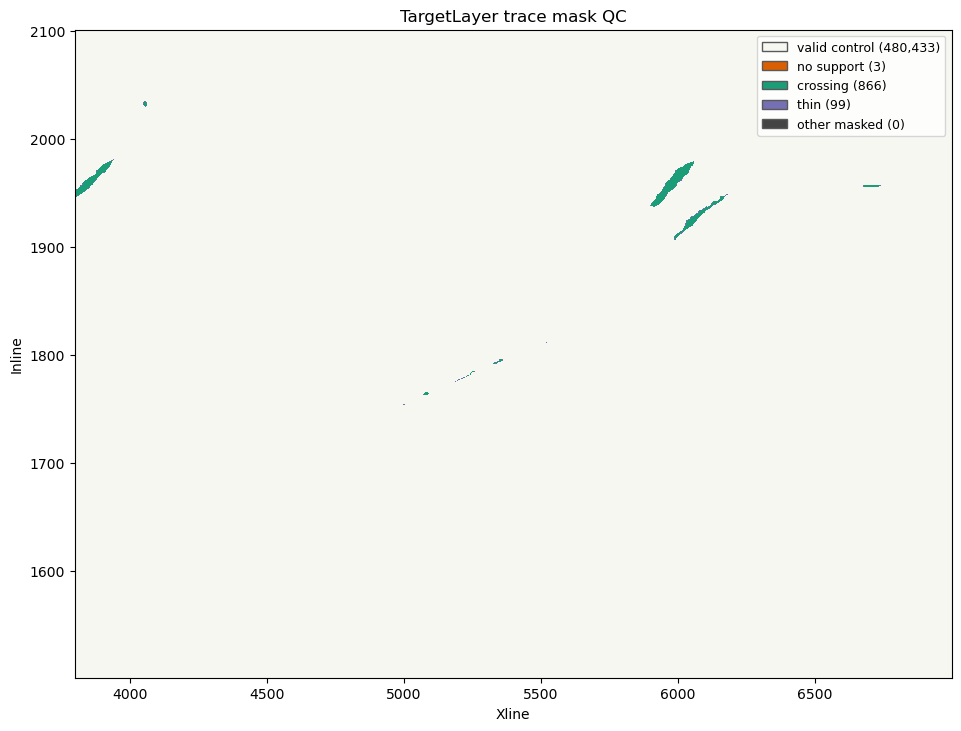

Saved: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\data\output_lfm_depth_from_las_20260428\target_layer_qc\target_layer_mask_plan_qc.png
masked_trace count: 968
filled_by_thickness_interpolation count: 968


In [22]:
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

qc_dir = output_dir / "target_layer_qc"
trace_qc_file = qc_dir / "target_layer_trace_qc.csv"
pair_qc_file = qc_dir / "target_layer_pair_qc.csv"
summary_qc_file = qc_dir / "target_layer_qc_summary.csv"

trace_qc = pd.read_csv(trace_qc_file, low_memory=False)
pair_qc = pd.read_csv(pair_qc_file, low_memory=False)
summary_qc = pd.read_csv(summary_qc_file, low_memory=False)

required_trace_columns = {
    "inline",
    "xline",
    "valid_control",
    "filled_model",
    "masked_trace",
    "filled_by_thickness_interpolation",
    "no_support",
    "crossing",
    "thin",
}
missing = required_trace_columns - set(trace_qc.columns)
if missing:
    raise ValueError(f"trace QC missing required columns: {sorted(missing)}")

ilines_qc = np.asarray(sorted(trace_qc["inline"].unique()), dtype=float)
xlines_qc = np.asarray(sorted(trace_qc["xline"].unique()), dtype=float)


def trace_grid(column: str, dtype=bool) -> np.ndarray:
    grid_df = trace_qc.pivot(index="inline", columns="xline", values=column).reindex(index=ilines_qc, columns=xlines_qc)
    return grid_df.to_numpy(dtype=dtype)


masked = trace_grid("masked_trace")
no_support = trace_grid("no_support")
crossing = trace_grid("crossing")
thin = trace_grid("thin")
filled_by_thickness = trace_grid("filled_by_thickness_interpolation")

# 0=valid, 1=no support, 2=crossing, 3=thin, 4=other masked.
# 若同一 trace 有多个原因，后写入的类别优先显示。
mask_reason = np.zeros(masked.shape, dtype=np.uint8)
mask_reason[masked] = 4
mask_reason[no_support] = 1
mask_reason[crossing] = 2
mask_reason[thin] = 3

reason_labels = {
    0: "valid control",
    1: "no support",
    2: "crossing",
    3: "thin",
    4: "other masked",
}
reason_colors = ["#f7f7f2", "#d95f02", "#1b9e77", "#7570b3", "#444444"]
cmap = ListedColormap(reason_colors)
norm = BoundaryNorm(np.arange(-0.5, 5.5, 1.0), cmap.N)

counts = pd.Series(mask_reason.ravel()).value_counts().reindex(range(5), fill_value=0)
qc_stats = pd.DataFrame(
    {
        "reason": [reason_labels[i] for i in range(5)],
        "trace_count": [int(counts.loc[i]) for i in range(5)],
        "ratio": [float(counts.loc[i] / mask_reason.size) for i in range(5)],
    }
)
display(qc_stats)
display(summary_qc)

fig, ax = plt.subplots(figsize=(9.5, 7.2), constrained_layout=True)
im = ax.imshow(
    mask_reason,
    origin="lower",
    aspect="auto",
    interpolation="nearest",
    extent=[xlines_qc[0], xlines_qc[-1], ilines_qc[0], ilines_qc[-1]],  # type: ignore
    cmap=cmap,
    norm=norm,
)
ax.set_title("TargetLayer trace mask QC")
ax.set_xlabel("Xline")
ax.set_ylabel("Inline")
handles = [
    Patch(facecolor=reason_colors[i], edgecolor="0.35", label=f"{reason_labels[i]} ({counts.loc[i]:,})")
    for i in range(5)
]
ax.legend(handles=handles, loc="upper right", frameon=True, fontsize=9)
ax.grid(False)

mask_plan_png = qc_dir / "target_layer_mask_plan_qc.png"
fig.savefig(mask_plan_png, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", mask_plan_png)
print("masked_trace count:", int(masked.sum()))
print("filled_by_thickness_interpolation count:", int(filled_by_thickness.sum()))
